<a href="https://colab.research.google.com/github/danadorn/lab6-clustering-student/blob/master/lab6_pca_ml_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Principal Component Analysis (PCA)
## Dimensionality Reduction and Machine Learning Performance

**Objective:** Understand and implement PCA for dimensionality reduction and compare machine learning model performance with and without PCA.

**Learning Outcomes:**
- Understand the concept of dimensionality reduction
- Apply PCA to reduce high-dimensional data
- Visualize data before and after dimensionality reduction
- Compare ML model performance with original vs PCA-transformed features
- Understand the trade-offs between dimensionality reduction and model accuracy


## Part 1: Setup and Data Loading

First, let's import the necessary libraries and load our dataset.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

# Set random seed for reproducibility
np.random.seed(42)

# Configure plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


### Load the Breast Cancer Dataset

The Breast Cancer dataset contains 569 samples with 30 features each - perfect for testing PCA!

In [ ]:
# TODO: Load the breast cancer dataset
# Hint: Use load_breast_cancer() function
cancer = None  # Replace None with the correct code

# Extract data and labels
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

# Display basic information
print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Target classes: {target_names}")
print(f"Class distribution: {np.bincount(y)}")

## Part 2: Data Preprocessing

Before applying PCA and training models, we need to:
1. Split data into training and testing sets
2. Standardize the features

In [ ]:
# TODO: Split the data into train and test sets (80-20 split)
# Hint: Use train_test_split with test_size=0.2 and random_state=42
X_train, X_test, y_train, y_test = None  # Replace None

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

In [ ]:
# TODO: Standardize the data
# Hint: Fit StandardScaler on training data, then transform both train and test
scaler = None  # Initialize StandardScaler
X_train_scaled = None  # Fit and transform training data
X_test_scaled = None  # Transform test data (don't fit!)

print(f"Original training data - Mean: {X_train.mean():.2f}, Std: {X_train.std():.2f}")
print(f"Scaled training data - Mean: {X_train_scaled.mean():.2f}, Std: {X_train_scaled.std():.2f}")

## Part 3: Understanding the Data - Correlation Analysis

Let's see why PCA might be useful by examining feature correlations.

In [ ]:
# Create correlation matrix
correlation_matrix = np.corrcoef(X_train_scaled.T)

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (30 features)', fontsize=14)
plt.tight_layout()
plt.show()

# Count highly correlated features
high_corr = np.sum(np.abs(correlation_matrix) > 0.8) - 30  # Subtract diagonal
print(f"Number of feature pairs with correlation > 0.8: {high_corr // 2}")
print("\nThis suggests redundancy - PCA can help!")

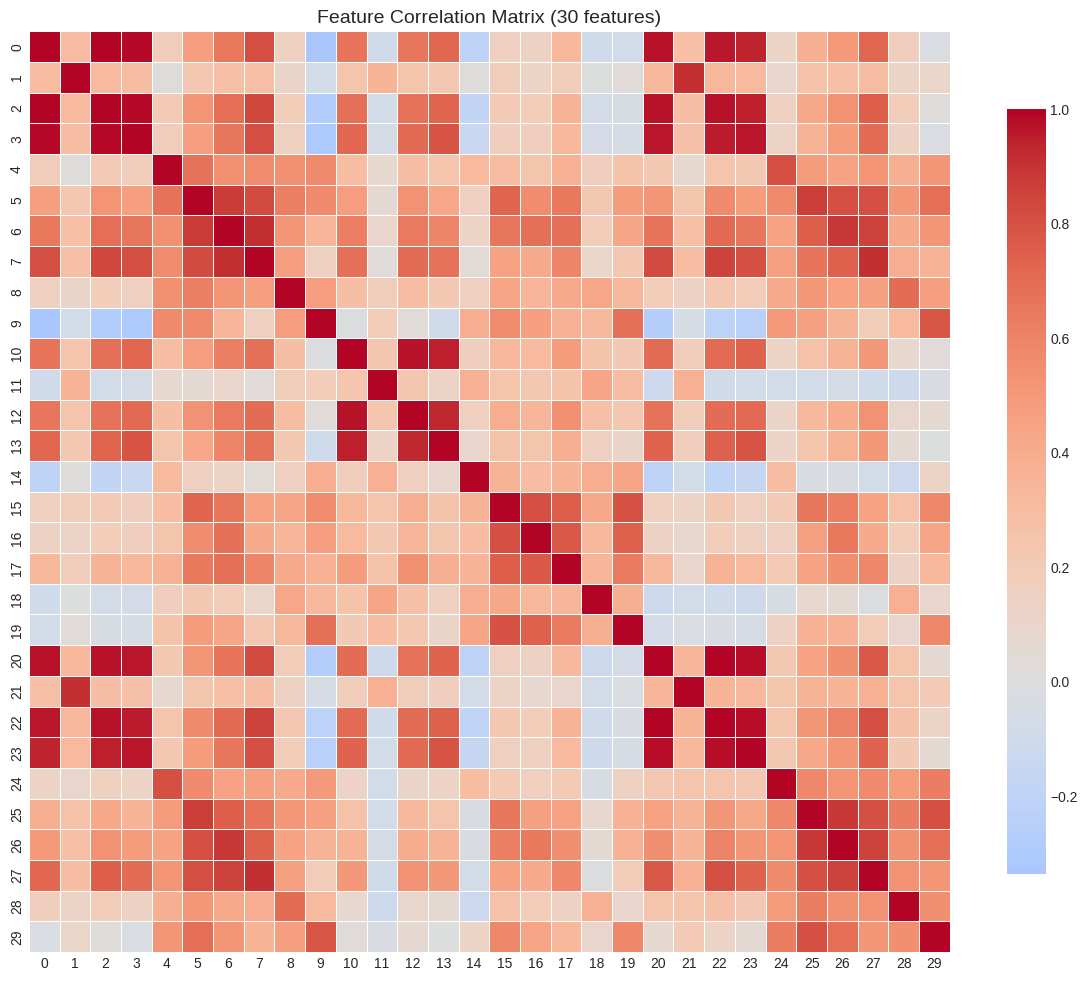

**Question:** Why might highly correlated features be a problem?

**Your Answer:**
_[Write your answer here]_

## Part 4: Applying PCA - Finding Optimal Components

Let's determine how many components we need to retain most of the variance.

In [ ]:
# TODO: Apply PCA with all components to analyze variance
# Hint: Don't specify n_components or set it to None
pca_full = None  # Replace None with PCA initialization
X_train_pca_full = None  # Replace None with fit_transform on training data

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Individual variance
ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('Variance Explained by Each Component')
ax1.set_xlim(0, 31)

# Cumulative variance
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.axhline(y=0.90, color='g', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 31)

plt.tight_layout()
plt.show()

# Find number of components for different thresholds
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nComponents needed for 90% variance: {n_components_90}")
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Original number of features: {X_train.shape[1]}")
print(f"\nDimensionality reduction: {X_train.shape[1]} → {n_components_95} features")

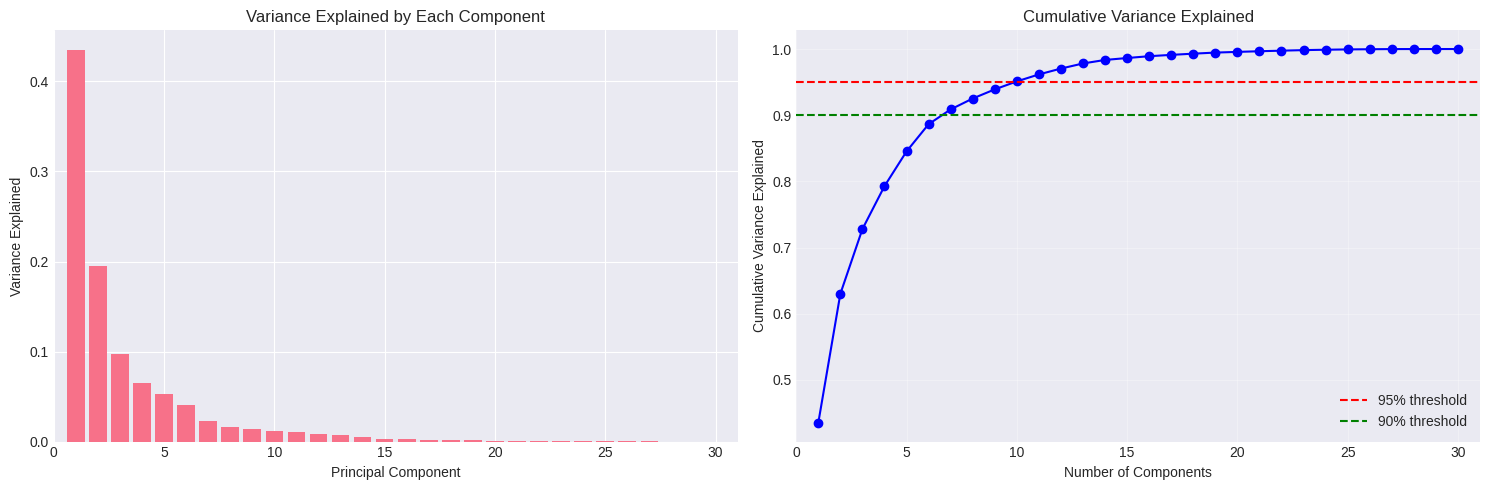

## Part 5: Prepare Different Feature Sets

We'll create multiple versions of our data:
1. Original features (30 features)
2. PCA with 95% variance
3. PCA with 90% variance
4. PCA with 5 components
5. PCA with 2 components (for visualization)

In [ ]:
# TODO: Create PCA transformations with different numbers of components

# PCA with 95% variance
pca_95 = None  # Initialize PCA with n_components for 95% variance
X_train_pca_95 = None  # Fit and transform training data
X_test_pca_95 = None  # Transform test data

# PCA with 90% variance
pca_90 = None  # Initialize PCA
X_train_pca_90 = None  # Fit and transform
X_test_pca_90 = None  # Transform

# PCA with 5 components
pca_5 = None  # Initialize PCA
X_train_pca_5 = None  # Fit and transform
X_test_pca_5 = None  # Transform

# PCA with 2 components (for visualization)
pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train_scaled)
X_test_pca_2 = pca_2.transform(X_test_scaled)

print("Feature set summary:")
print(f"1. Original features: {X_train_scaled.shape[1]} features")
print(f"2. PCA 95% variance: {X_train_pca_95.shape[1]} features")
print(f"3. PCA 90% variance: {X_train_pca_90.shape[1]} features")
print(f"4. PCA 5 components: {X_train_pca_5.shape[1]} features")
print(f"5. PCA 2 components: {X_train_pca_2.shape[1]} features")

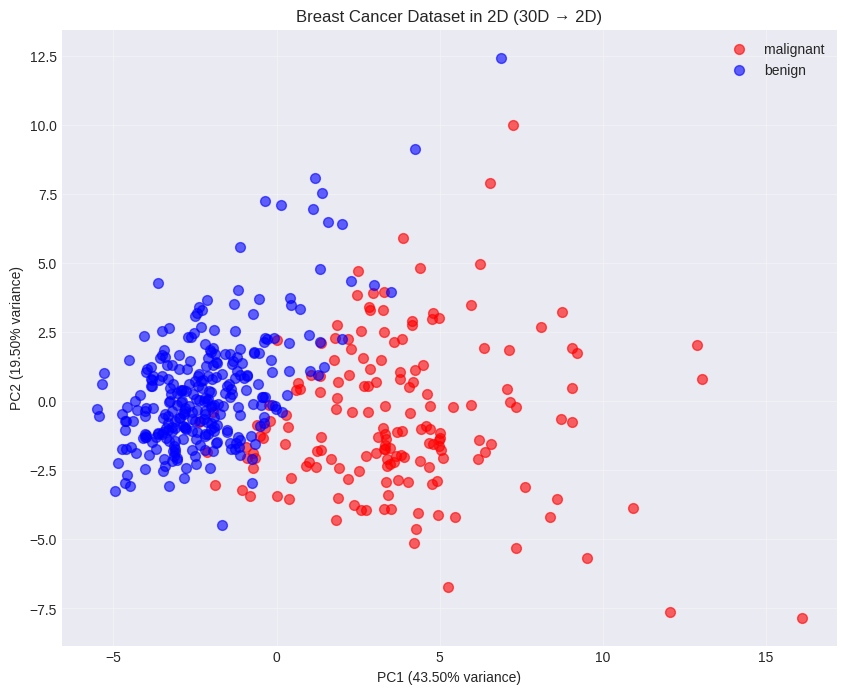

### Visualize Data in 2D

In [ ]:
# Visualize the 2D PCA projection
plt.figure(figsize=(10, 8))

colors = ['red', 'blue']
for i, (color, target_name) in enumerate(zip(colors, target_names)):
    plt.scatter(X_train_pca_2[y_train==i, 0], X_train_pca_2[y_train==i, 1],
                color=color, label=target_name, alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Breast Cancer Dataset in 2D (30D → 2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total variance captured in 2D: {pca_2.explained_variance_ratio_.sum():.2%}")

## Part 6: Model Performance Comparison

### Part 6.1: Support Vector Machine (SVM)

In [ ]:
# TODO: Train SVM on all feature sets and compare performance

# Prepare data dictionary
feature_sets = {
    'Original (30)': (X_train_scaled, X_test_scaled),
    f'PCA 95% ({X_train_pca_95.shape[1]})': (X_train_pca_95, X_test_pca_95),
    f'PCA 90% ({X_train_pca_90.shape[1]})': (X_train_pca_90, X_test_pca_90),
    'PCA 5': (X_train_pca_5, X_test_pca_5),
    'PCA 2': (X_train_pca_2, X_test_pca_2)
}

svm_results = []

for name, (X_tr, X_te) in feature_sets.items():
    # TODO: Initialize SVM classifier with kernel='rbf', random_state=42
    svm = None  # Replace None

    # Train the model and measure time
    start_time = time.time()
    None  # Replace with fit command
    train_time = time.time() - start_time

    # Make predictions and measure time
    start_time = time.time()
    y_pred = None  # Replace with predict command
    predict_time = time.time() - start_time

    # Calculate accuracy
    accuracy = None  # Replace with accuracy_score calculation

    svm_results.append({
        'Feature Set': name,
        'Accuracy': accuracy,
        'Train Time (s)': train_time,
        'Predict Time (s)': predict_time
    })

# Display results
svm_df = pd.DataFrame(svm_results)
print("\n=== SVM Performance Comparison ===")
print(svm_df.to_string(index=False))

**Question:** What do you observe about SVM's accuracy and training time with different feature sets?

**Your Answer:**
_[Write your answer here]_

### Part 6.2: Random Forest Classifier

In [ ]:
# TODO: Train Random Forest on all feature sets
rf_results = []

for name, (X_tr, X_te) in feature_sets.items():
    # TODO: Initialize Random Forest with n_estimators=100, random_state=42
    rf = None  # Replace None

    start_time = time.time()
    None  # Fit the model
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = None  # Make predictions
    predict_time = time.time() - start_time

    accuracy = None  # Calculate accuracy

    rf_results.append({
        'Feature Set': name,
        'Accuracy': accuracy,
        'Train Time (s)': train_time,
        'Predict Time (s)': predict_time
    })

rf_df = pd.DataFrame(rf_results)
print("\n=== Random Forest Performance Comparison ===")
print(rf_df.to_string(index=False))

### Part 6.3: K-Nearest Neighbors (KNN)

In [ ]:
# TODO: Train KNN on all feature sets
knn_results = []

for name, (X_tr, X_te) in feature_sets.items():
    # TODO: Initialize KNN with n_neighbors=5
    knn = None  # Replace None

    start_time = time.time()
    None  # Fit the model
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = None  # Make predictions
    predict_time = time.time() - start_time

    accuracy = None  # Calculate accuracy

    knn_results.append({
        'Feature Set': name,
        'Accuracy': accuracy,
        'Train Time (s)': train_time,
        'Predict Time (s)': predict_time
    })

knn_df = pd.DataFrame(knn_results)
print("\n=== K-Nearest Neighbors Performance Comparison ===")
print(knn_df.to_string(index=False))

### Part 6.4: Logistic Regression

In [ ]:
# TODO: Train Logistic Regression on all feature sets
lr_results = []

for name, (X_tr, X_te) in feature_sets.items():
    # TODO: Initialize Logistic Regression with max_iter=10000, random_state=42
    lr = None  # Replace None

    start_time = time.time()
    None  # Fit the model
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = None  # Make predictions
    predict_time = time.time() - start_time

    accuracy = None  # Calculate accuracy

    lr_results.append({
        'Feature Set': name,
        'Accuracy': accuracy,
        'Train Time (s)': train_time,
        'Predict Time (s)': predict_time
    })

lr_df = pd.DataFrame(lr_results)
print("\n=== Logistic Regression Performance Comparison ===")
print(lr_df.to_string(index=False))

## Part 7: Comprehensive Comparison and Visualization

In [ ]:
# Combine all results
all_results = []

for model_name, df in [('SVM', svm_df), ('Random Forest', rf_df),
                        ('KNN', knn_df), ('Logistic Regression', lr_df)]:
    for _, row in df.iterrows():
        all_results.append({
            'Model': model_name,
            'Feature Set': row['Feature Set'],
            'Accuracy': row['Accuracy'],
            'Train Time (s)': row['Train Time (s)']
        })

results_df = pd.DataFrame(all_results)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
pivot_acc = results_df.pivot(index='Feature Set', columns='Model', values='Accuracy')
pivot_acc.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Feature Set')
axes[0].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.85, 1.0])
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Training time comparison
pivot_time = results_df.pivot(index='Feature Set', columns='Model', values='Train Time (s)')
pivot_time.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_xlabel('Feature Set')
axes[1].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

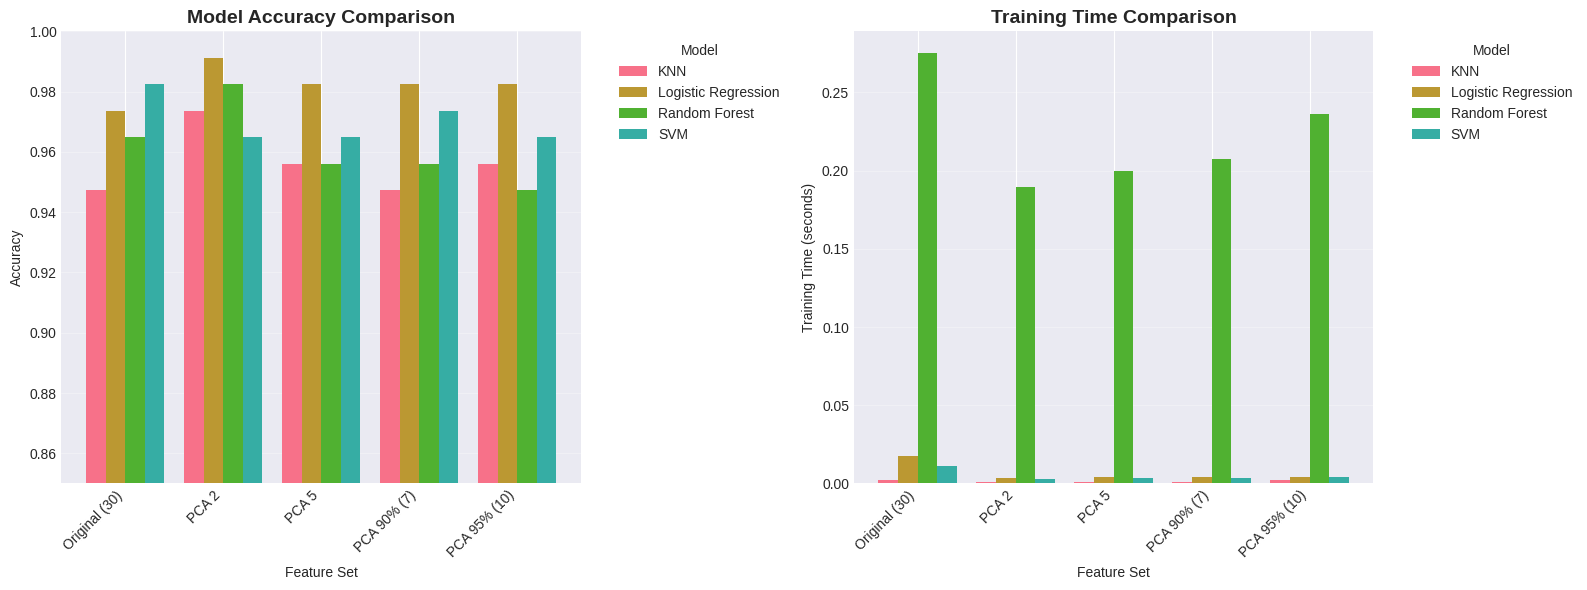

## Part 8: Detailed Analysis - SVM with Best PCA Setting

In [ ]:
# Train SVM on original vs best PCA setting for detailed comparison
svm_original = SVC(kernel='rbf', random_state=42)
svm_original.fit(X_train_scaled, y_train)
y_pred_original = svm_original.predict(X_test_scaled)

svm_pca = SVC(kernel='rbf', random_state=42)
svm_pca.fit(X_train_pca_95, y_train)
y_pred_pca = svm_pca.predict(X_test_pca_95)

# Create confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original features
cm_original = confusion_matrix(y_test, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f'SVM with Original Features (30)\nAccuracy: {accuracy_score(y_test, y_pred_original):.4f}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# PCA features
cm_pca = confusion_matrix(y_test, y_pred_pca)
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title(f'SVM with PCA Features ({X_train_pca_95.shape[1]})\nAccuracy: {accuracy_score(y_test, y_pred_pca):.4f}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print classification reports
print("\n=== SVM with Original Features ===")
print(classification_report(y_test, y_pred_original, target_names=target_names))

print(f"\n=== SVM with PCA Features ({X_train_pca_95.shape[1]} components) ===")
print(classification_report(y_test, y_pred_pca, target_names=target_names))

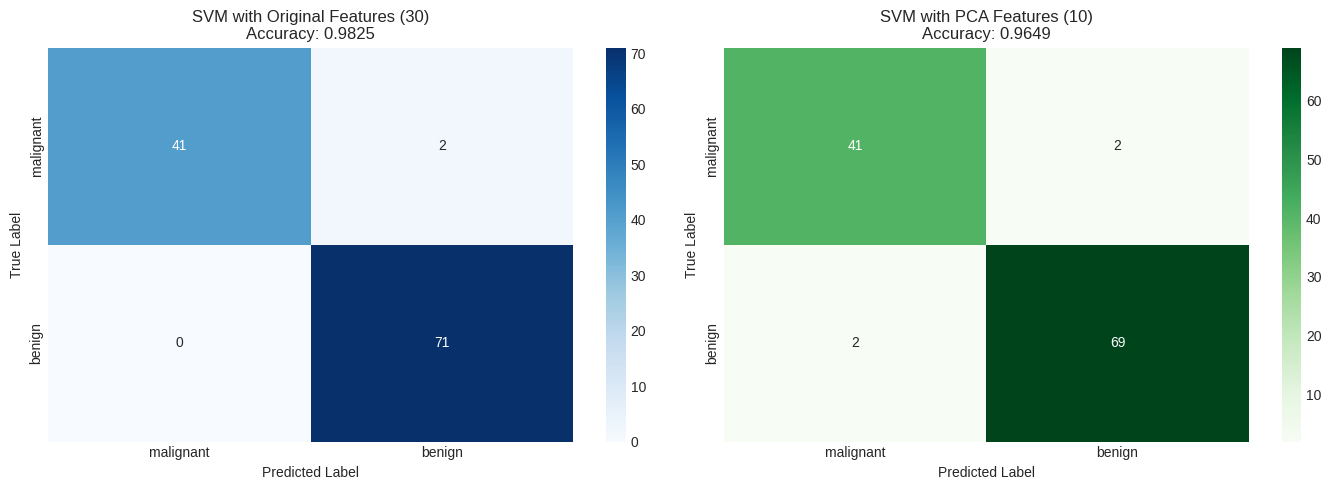

## Part 9: Summary Statistics Table

In [ ]:
# Create summary table showing best results for each model
summary_data = []

for model_name, df in [('SVM', svm_df), ('Random Forest', rf_df),
                        ('KNN', knn_df), ('Logistic Regression', lr_df)]:
    # Best with original features
    orig = df[df['Feature Set'] == 'Original (30)'].iloc[0]
    # Best with PCA
    pca_best = df[df['Feature Set'] != 'Original (30)'].nlargest(1, 'Accuracy').iloc[0]

    summary_data.append({
        'Model': model_name,
        'Original Accuracy': f"{orig['Accuracy']:.4f}",
        'Original Time (s)': f"{orig['Train Time (s)']:.4f}",
        'Best PCA Setting': pca_best['Feature Set'],
        'PCA Accuracy': f"{pca_best['Accuracy']:.4f}",
        'PCA Time (s)': f"{pca_best['Train Time (s)']:.4f}",
        'Accuracy Diff': f"{(pca_best['Accuracy'] - orig['Accuracy']):.4f}",
        'Time Speedup': f"{(orig['Train Time (s)'] / pca_best['Train Time (s)']):.2f}x"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("FINAL SUMMARY: Original vs Best PCA Configuration")
print("="*100)
print(summary_df.to_string(index=False))
print("\nNote: Positive Accuracy Diff means PCA improved performance")
print("      Time Speedup shows how many times faster training was with PCA")

## Part 10: Reflection Questions

Answer the following questions based on your experiments:

1. **Which model benefited most from PCA dimensionality reduction? Why do you think this happened?**
   
   _[Your answer here]_

2. **Did any model perform worse with PCA compared to original features? What might explain this?**
   
   _[Your answer here]_

3. **Compare the training time with original features vs PCA features. What pattern do you observe?**
   
   _[Your answer here]_

4. **Looking at the PCA with 2 components (only 2 features), the accuracy is still quite high for some models. What does this tell you about the original 30 features?**
   
   _[Your answer here]_

5. **In real-world applications, when would you choose to use PCA before training a model?**
   
   _[Your answer here]_

6. **What is the trade-off between using PCA with 90% vs 95% variance?**
   
   _[Your answer here]_

## Bonus Challenge (Optional)

Try the following:
1. Load the digits dataset (load_digits) which has 64 features
2. Apply the same analysis
3. Compare results with the breast cancer dataset
4. Which dataset benefits more from PCA? Why?

In [ ]:
# Your code here
